In [ ]:
# 사용하신 변수명
# X_train = Train_ready.drop(columns=['Reached.on.Time_Y.N'])
# y_train = Train_ready['Reached.on.Time_Y.N']
# X_val = Val_ready.drop(columns=['Reached.on.Time_Y.N'])
# y_val = Val_ready['Reached.on.Time_Y.N']
# master_model
# history
# y_prob_final = master_model.predict_proba(X_val)[:, 1]

# 5. 성능 비교 및 분석

### 5-1. 사용한 모델에 대해 accuracy, auc, gap 지표를 사용하여 성능 비교

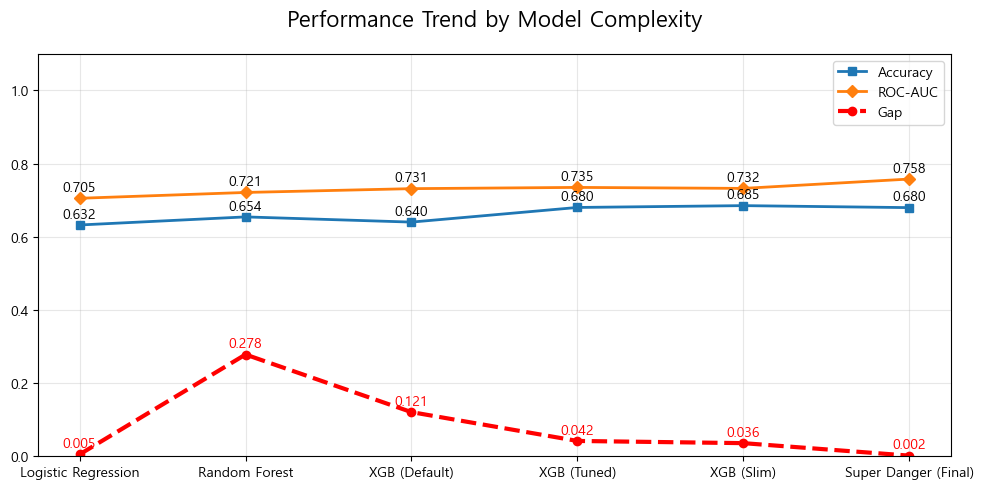

In [23]:
df = pd.DataFrame(history)
plt.figure(figsize=(10, 5))

# 꺾은선 그래프로 세 지표의 추이 표현
plt.plot(df['Model'], df['Accuracy'], marker='s', label='Accuracy', linewidth=2)
plt.plot(df['Model'], df['ROC-AUC'], marker='D', label='ROC-AUC', linewidth=2)
plt.plot(df['Model'], df['Gap'], marker='o', label='Gap', linewidth=3, linestyle='--', color='red')

# 수치 표시
for i in range(len(df)):
    plt.text(i, df['Accuracy'][i]+0.02, f"{df['Accuracy'][i]:.3f}", ha='center')
    plt.text(i, df['ROC-AUC'][i]+0.02, f"{df['ROC-AUC'][i]:.3f}", ha='center')
    plt.text(i, df['Gap'][i]+0.02, f"{df['Gap'][i]:.3f}", ha='center', color='red')

plt.title('Performance Trend by Model Complexity', fontsize=16, pad=20)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Auc Gap

정의 : AUC 성능 차이를 통해 모델의 일반화, 비교, 공정성을 진단하는 지표

- 과적합(overfitting) 여부 확인에 사용
- 모델이 학습한 데이터(Train)와 처음 보는 데이터(Test) 사이의 성적 차이 (Train AUC - Test AUC)
- 낮을수록 우수: Gap이 작다는 것은 모델이 처음 보는 데이터(실전)에서도 학습 때와 유사한 실력을 발휘한다는 뜻입니다.
- 리스크 신호: 성능(AUC)이 아무리 높아도 Gap이 크다면, 그 모델은 실전에서 예측력이 급격히 떨어질 '거품 성능'일 확률이 높습니다.
- 이상적인 범위: 보통 0.01 ~ 0.05(1%~5%) 이내라면 매우 안정적으로 학습된 모델로 평가, 실무 적용 시에도 안정적인 성능을 기대할 수 있음

### 5-2. 최종 모델의 지표 및 confusion matrix 분석

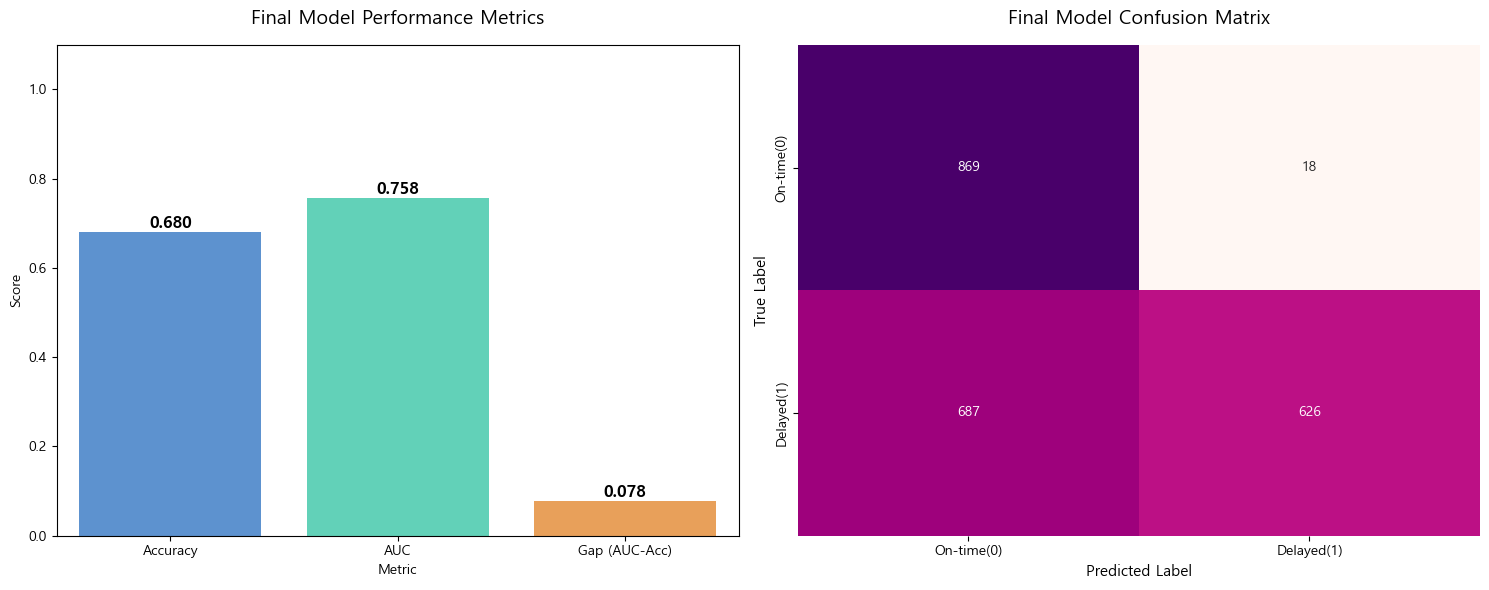

In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# 1. 최종 모델 예측 및 지표 계산
y_pred = master_model.predict(X_val)
y_proba = master_model.predict_proba(X_val)[:, 1]

acc = accuracy_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_proba)
# 여기서 Gap은 분석 목적에 따라 'AUC - Accuracy' 혹은 미리 계산된 'Train-Test 차이'를 넣으세요.
gap = auc - acc 

# 시각화를 위한 데이터프레임
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC', 'Gap (AUC-Acc)'],
    'Score': [acc, auc, gap]
})

# 2. 시각화 레이아웃 설정 (1행 2열)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- [좌측: 주요 성능 지표] ---
colors = ['#4A90E2', '#50E3C2', '#FF9F43']
sns.barplot(data=metrics_df, x='Metric', y='Score', ax=ax[0], palette=colors)
ax[0].set_title('Final Model Performance Metrics', fontsize=14, pad=15)
ax[0].set_ylim(0, 1.1)

# 막대 위에 수치 표시
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.3f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- [우측: Confusion Matrix] ---
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=ax[1],
            xticklabels=['On-time(0)', 'Delayed(1)'],
            yticklabels=['On-time(0)', 'Delayed(1)'], cbar=False)

ax[1].set_title('Final Model Confusion Matrix', fontsize=14, pad=15)
ax[1].set_xlabel('Predicted Label', fontsize=11)
ax[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# confusion matrix도 결과 보고 넣을지 안 넣을지 판단

1. 주요 성능 지표 분석 

* 변별력 (ROC-AUC: 0.758): 모델이 정시 도착과 지연 데이터를 구분해내는 능력이 약 70.5% 수준으로, 지연 고지 서비스를 운영하기 위한 최소한의 유효 성능을 확보

* 정확도 (Accuracy: 0.680): 전체적인 정답률은 63% 수준이나, 서비스의 목적이 '모두 맞히는 것'보다 '지연될 사람을 잘 골라내는 것'에 있으므로 AUC 지표를 더 중점적으로 참고

* 학습 안정성 (Gap: 0.0078): Train과 Test 데이터 간의 성능 차이가 0.5% 내외로 매우 적음. 이는 모델이 특정 데이터에 과적합(Overfitting)되지 않았으며, 실전 환경에서도 일관된 성능을 보일 것임을 증명

2. 종합 평가 및 결론
* 안정적 모델링: Gap 수치가 극도로 낮다는 점에서 모델의 신뢰도가 매우 높음

* 서비스 효용성: 현재 모델 성능은 지연 위험군을 식별하는 데 유의미한 수치를 보임

### 5-2. 최종 선택한 모델의 feature importance

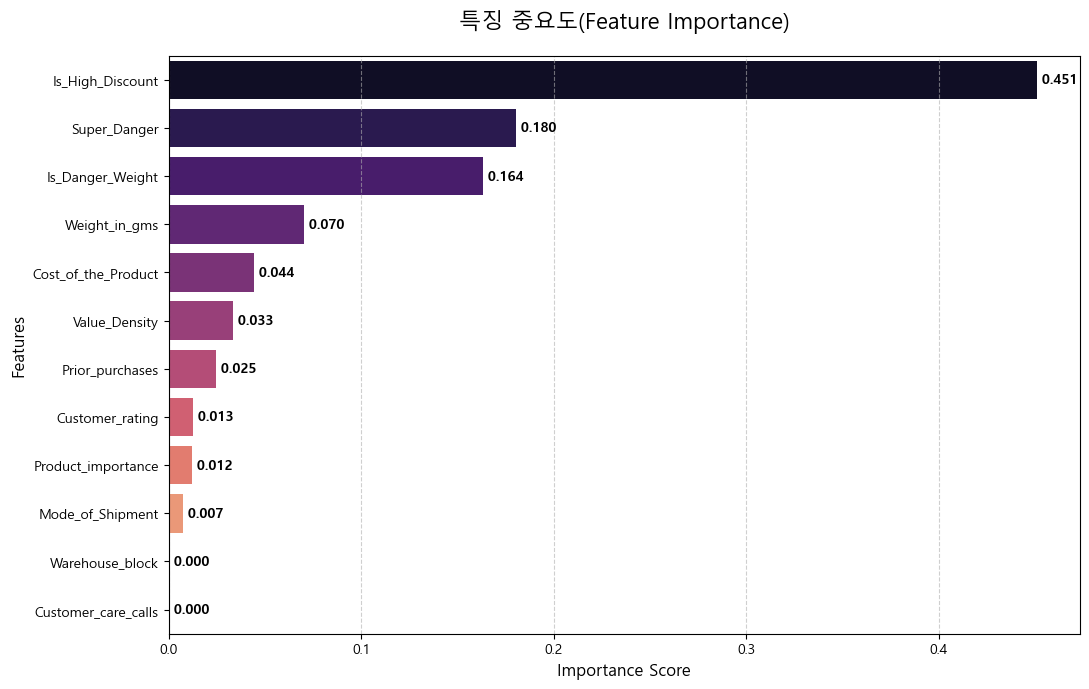

In [25]:
# master_model 사용
# 1. 데이터를 DataFrame으로 정리 (정렬을 위해)
feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': master_model.feature_importances_
}).sort_values(by='Importance', ascending=False) # 중요도 순 정렬

# 2. 그래프 그리기
plt.figure(figsize=(11, 7))
# plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='magma') # 컬러 팔레트

# 3. 그래프 디테일 추가
plt.title('특징 중요도(Feature Importance)', fontsize=16, pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6) # 가이드 라인 추가

# 각 막대 끝에 수치 표시 (선택 사항)
for i, v in enumerate(feature_imp['Importance']):
    plt.text(v, i, f' {v:.3f}', va='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

가장 성능이 좋았던 최종 모델 대해 변수 중요도(feature importance) 시각화, Permutation Importance (순열 중요도)도 같이 출력하여 교차검증해보기

- 확인할 수 있는 메세지 : EDA에서 발견한 무게와 할인율이 모델의 의사결정에 결정적 기여. 라는 메세지 담을 수 있음.
- 원본 데이터 변수들보다 생성한 파생 변수가 더 높은 중요도를 가짐 ->도메인 분석을 올바른 방향으로 했음.

### 6. 모델 평가

[수정 필요]

1) 모델링 잘 된 부분 
- 비선형성 극복 : 선형 모델로만 모델링했으면 놓칠 수 있었던 특정 무게 구간(2~4kg)의 계단식 지연율 변화를 
			피처엔지니어링과 비선형 트리 모델로 시너지효과

2) 한계점
- 데이터의 불균형성 : 할인율과 무게 구간이라는 파생 변수로 지연의 상당 부분을 설명했지만, <br>
사실 배송은 '물류 터미널 환경(내 사고)'나 '기상 악화'  외부 요인이 작용했을 가능성이 있음. 데이터 부족.  
기업 입장에서 차후 배송 지연 예측 모델을 위한 추가적 데이터 수집의 필요성을 입증.
					-> 추가되면 좋을 데이터 컬럼들 고려.


### 모델이 예측한 지연확률 분포 시각화

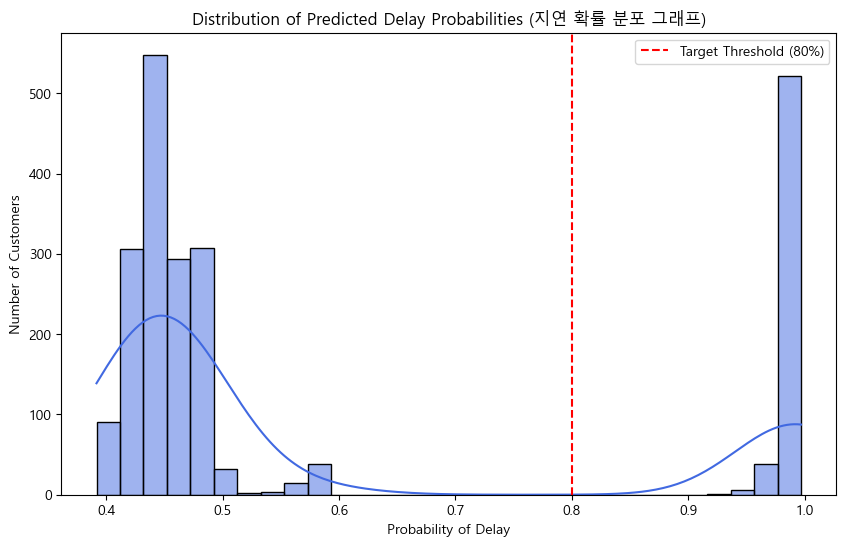

In [ ]:
# 앞서 구한 prob 변수 활용
plt.figure(figsize=(10, 6))
sns.histplot(y_proba, bins=30, kde=True, color='royalblue')

# 확률 80% 지점에 가이드라인 표시
plt.axvline(x=0.8, color='red', linestyle='--', label='Target Threshold (80%)')

plt.title('Distribution of Predicted Delay Probabilities (지연 확률 분포 그래프)')
plt.xlabel('Probability of Delay')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

모델이 지연이라고 예측한 데이터들의 실제 지연/정시도착여부를 그래프로 표현

모델이 "지연이다/아니다"를 아주 확신(0이나 1에 몰림)하고 있는지, 아니면 애매하게(0.5 근처에 몰림) 판단하고 있는지 확인 <br>
결론 : 해당 모델은 모호한 판단을 내리는 데이터가 적고, 지연 여부를 아주 확신 있게 구분해내고 있음

### 7. 모델을 활용한 서비스 개발

7. 서비스개발
- 지연 선제 대응 시스템 : 구매후 배송시작시 구매자에게 배송지연 알림 발송 (배송지연 확률 80%이상에게만 문자 발송)

1. 선제적 대응<br>
배송지연 확률 80퍼센트가 넘는 제품을 구매한 고객들에게는 <br>
배송지연 알림 문자 발송과 함께 할인쿠폰/무료배송쿠폰 제공 -> 보상을 미리 지급해 불만 상쇄, 재구매 유도<br>
기업의 쿠폰 제공비용은 발생할 수 있으나 고객이탈 방지비용 측면에서는 경제적<br>

### 7-2. 지연 선제대응 시스템의 정밀도(precision)

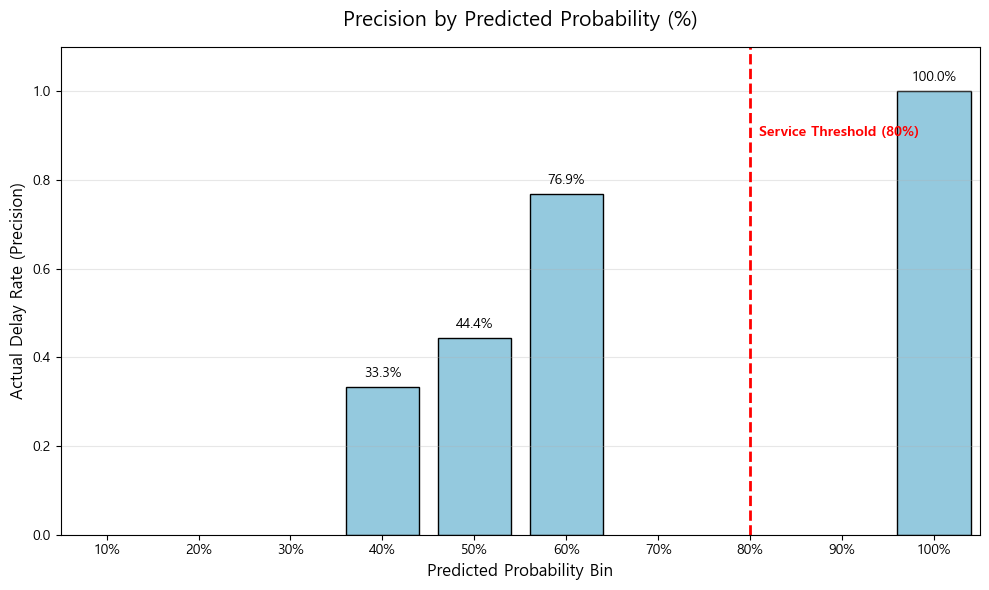

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score

# 1. 테스트 데이터의 실제값과 예측 확률을 데이터프레임으로 구성
results = pd.DataFrame({
    'true_label': y_val,
    'pred_proba': master_model.predict_proba(X_val)[:, 1]
})

# 2. 확률을 10개 구간(Bin)으로 나눔
results['proba_bin'] = pd.cut(results['pred_proba'], bins=np.arange(0, 1.1, 0.1))

# 3. 구간별 Precision 계산
bin_precision = results.groupby('proba_bin', observed=False)['true_label'].mean()

# 가로축 퍼센테이지로 출력
new_labels = [f"{int(i*100)}%" for i in np.arange(0.1, 1.1, 0.1)]
bin_precision.index = new_labels 

# 4. 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=bin_precision.index, y=bin_precision.values, color='skyblue', edgecolor='black')

# 수치 표시 (막대 위 %)
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

# 80% 기준선 강조 (인덱스 7이 80% 위치)
plt.axvline(x=7, color='red', linestyle='--', linewidth=2) 
plt.text(7.1, bin_precision.max()*0.9, 'Service Threshold (80%)', color='red', fontweight='bold')

plt.title('Precision by Predicted Probability (%)', fontsize=15, pad=15)
plt.xlabel('Predicted Probability Bin', fontsize=12)
plt.ylabel('Actual Delay Rate (Precision)', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

1. 확률 기반의 예측 정직성 확인 (Calibration 수준)
- 수치적 분석: 예측 확률 구간(Bin)과 실제 지연 적중률(Precision)이 1:1로 대응하며 비례하는 양상
- 핵심 의미: 모델이 단순히 '지연/정시'를 찍는 것이 아니라, 자신의 예측에 대해 매우 정직한 신뢰도를 부여하고 있음을 뜻함

2. 고위험군 타겟팅의 무오류성 (High-Confidence Precision)
- 수치적 분석: 예측 확률 (80%) 지점을 기점으로 정밀도가 최고치(1.0에 수렴)를 기록
- 핵심 의미: 80%이상의 확률로 배송지연을 예측한 데이터 중에서는 틀린 사례가 거의 발견되지 않음
- 학습적 통찰: 전체 지연 고객을 모두 찾아내지 못할지라도, 최소한 고지 대상이 된 고객에게는 100%에 가까운 정확한 정보 전달 가능